# DS 3000 - Assignment 4

**Student Name**: Gauri Rajesh

**Date**: 5/12/25


### Submission Instructions
Submit this `ipynb` file to canvas.

The `ipynb` format stores outputs from the last time you ran the notebook.  (When you open a notebook it has the figures and outputs of the last time you ran it too).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh run `Kernel > Restart & Run All` just before uploading the `ipynb` file to Canvas.

### Academic Integrity

**Writing your homework is an individual effort.**  You may discuss general python problems with other students but under no circumstances should you observe another student's code which was written for this assignment, from this year or past years.  Pop into office hours or DM us in MS Teams if you have a specific question about your work or if you would like another pair of eyes or talk through your code.

Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment. You do not need to cite the official python documentation.

**Documentation / style counts for credit**  Please refer to the Pep-8 style, to improve the readability and consistency of your Python code. For more information, read the following article [How to Write Beautiful Python Code With PEP 8](https://realpython.com/python-pep8/) or ask your TA's for tips.

**NOTE:<span style='color:red'> Write python expressions to answer ALL questions below and ensure that you use the `print()` function to display the output.</span>** Each question should be answered in a new code cell. For example, your solution for question 1.1 should be in a different code cell from your solution for question 1.2.

## Data Science Problem (50 pts)
### Instructions

You are hired as a Data Scientist for the NYC Taxi and Limousine Commission (TLC) and this company routinely collects trip data from all licensed cabs in NY. Your team would like to use this data in the future to understand how New Yorkers use these taxis. Your first assignment is to **analyze the data of the Green Taxis, and determine if its a viable source.**

Your supervisor has requested that you perform your analysis using data from February 2023 and would like for you to present your findings during the next team meeting. Use a Jupyter notebook to explain your data wrangling and analytical steps to your colleagues. 

**Data & Documentation**

- **Data Source:** https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-02.parquet
- **Data Dictionary:** [Green Trips Data Dictionary](https://www1.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf).

The TLC trip record data and a description of the initiative can be found at the following link: https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page

**`Note:`** Ensure that you explain the results from each question.


**In this assignment you will use the Pandas library. Pandas allows us to load data that's stored in a various formats, e.g. excel, csv, txt, parquet, etc. In this assignment, you will learn to read data in parquet format which is one of the preferred formats when working with `Big Data`. [Click here to learn more about parquet files](https://towardsdatascience.com/csv-files-for-storage-no-thanks-theres-a-better-option-72c78a414d1d)**

I also provided starter code below to help you to read the data in parquet format. First, you'll need to install a new library called *fastparquet*.

In [1]:
#run this cell to install the fast parquet library
import pandas as pd
!pip install fastparquet

Defaulting to user installation because normal site-packages is not writeable


## 1. Load the data
Load the NYC Green Taxi Trip Records data directly from the URL into a data frame called tripdata_df. 

In [2]:
#let's load the data into a dataframe

tripdata_df = pd.read_parquet(path = 'https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2023-02.parquet',
                      engine = 'fastparquet')

#Note: you'll notice two new things. 1) We are using a new function called `read_parquet()` which indicates that we are 
#      reading data in parquet format. 2) We used the fastparquet library as the engine. 
#      That's it! Pandas will load the data into a dataframe. You can now use the dataframe for EDA.

# Reminder: How does Pandas read other file formats?
# 1. Excel files: pd.read_excel()
# 2. CSV Files: pd.read_csv()
# ... and now you know how to read parquet files using pd.read_parquet()


## 2. Inspect the Data (5 pts) 
Inspect the data and perform the following: 
1. display the dimensions, and indicate if the variables have suitable types.
2. convert all variables to suitable types

In [3]:
# inspect the dimensions
print(f"There are {tripdata_df.shape[0]} rows and {tripdata_df.shape[1]} columns.")

# inspect data types
tripdata_df.info()

There are 64809 rows and 20 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64809 entries, 0 to 64808
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               64809 non-null  float64       
 1   lpep_pickup_datetime   64809 non-null  datetime64[us]
 2   lpep_dropoff_datetime  64809 non-null  datetime64[us]
 3   store_and_fwd_flag     59988 non-null  object        
 4   RatecodeID             59988 non-null  float64       
 5   PULocationID           64809 non-null  float64       
 6   DOLocationID           64809 non-null  float64       
 7   passenger_count        59988 non-null  float64       
 8   trip_distance          64809 non-null  float64       
 9   fare_amount            64809 non-null  float64       
 10  extra                  64809 non-null  float64       
 11  mta_tax                64809 non-null  float64       
 12  tip_amount             

In [4]:
# change all ids, payment type, trip type, to integers since set values
tripdata_df["VendorID"] = tripdata_df["VendorID"].astype("Int64")
tripdata_df["RatecodeID"] = tripdata_df["RatecodeID"].astype("Int64")
tripdata_df["PULocationID"] = tripdata_df["PULocationID"].astype("Int64")
tripdata_df["DOLocationID"] = tripdata_df["DOLocationID"].astype("Int64")

# change store_and_fwd_flag to string
tripdata_df["store_and_fwd_flag"] = tripdata_df["store_and_fwd_flag"].astype("string")

# change passenger count to integers
tripdata_df["passenger_count"] = tripdata_df["passenger_count"].astype("Int64")

# change payment_type to whole number since set values
tripdata_df["payment_type"] = tripdata_df["payment_type"].astype("Int64")

# change trip_type to whole number since set types
tripdata_df["trip_type"] = tripdata_df["trip_type"].astype("Int64")

# verify changes occured
tripdata_df.dtypes

VendorID                          Int64
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag       string[python]
RatecodeID                        Int64
PULocationID                      Int64
DOLocationID                      Int64
passenger_count                   Int64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                      Int64
trip_type                         Int64
congestion_surcharge            float64
dtype: object

In [5]:
# inspect first few data entries
tripdata_df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1,2023-02-01 00:46:22,2023-02-01 01:05:57,N,1,74,265,1,10.80,42.9,1.0,1.5,0.00,0.0,NaN,1.0,45.40,2,1,0.00
1,2,2023-02-01 00:05:09,2023-02-01 00:22:42,N,1,216,196,1,4.76,23.3,1.0,0.5,0.00,0.0,NaN,1.0,25.80,2,1,0.00
2,2,2023-02-01 00:03:47,2023-02-01 00:27:30,N,1,7,114,1,6.32,30.3,1.0,0.5,8.89,0.0,NaN,1.0,44.44,1,1,2.75
3,2,2023-01-31 23:30:56,2023-01-31 23:51:40,N,1,74,239,1,3.50,16.3,1.0,0.5,0.00,0.0,NaN,1.0,21.55,2,1,2.75
4,2,2023-02-01 00:15:05,2023-02-01 00:26:02,N,1,82,223,1,3.14,17.0,1.0,0.5,0.00,0.0,NaN,1.0,19.50,2,1,0.00


## 3. Types of Data (2 pts) 
Are there any categorical data in this dataset. If they exist, demonstrate at least two categorical variables and indicate if they are nominal or ordinal (hint: read the data dictionary above which describes all fields in the data)

In [6]:
tripdata_df["VendorID"].unique()

<IntegerArray>
[1, 2]
Length: 2, dtype: Int64

In [7]:
tripdata_df["payment_type"].unique()

<IntegerArray>
[2, 1, 3, 4, <NA>]
Length: 5, dtype: Int64

Based on the data dictionary and above code, VendorID is a nominal categorical variable since it can only be one of the values 1, 2, or 6(none in this dataset) but the LPEP providers do not have a specific order.  Payment_type is another nominal categorical variable since it can only be one of the values 0, 1, 2, 3, 4, 5, or 6 but they do not have specific order either.  For example, there is no ranking between using a credit card, cash, or flex fare trip.  Both of these variables have a limited set of possible values even though they are numerical, making them categorical.  

## 4. Missing Values (10 pts) 
Evaluate the frequency of missing values in the dataset and perform the following:
1. explain if missing values are an isolated case or a widespread issue? 
2. what method would you recommend to handle missing data?
3. write the suitable code to handle the missing values.

In [8]:
# check frequency of null values in each column
tripdata_df.isnull().sum()
# check percentage of missing values
tripdata_df.isnull().mean()*100
print("Missing values are not a widespread issue since they are present in the variables ehail_fee which has no data at all, RatecodeID, passenger_count,"
+ "payment_type, trip_type, and congestion_surcharge.")
print("ehail_fee column will be removed because there is no data at all")

Missing values are not a widespread issue since they are present in the variables ehail_fee which has no data at all, RatecodeID, passenger_count,payment_type, trip_type, and congestion_surcharge.
ehail_fee column will be removed because there is no data at all


In [9]:
# based on information below, ehail_fee, store_and_fwd_flag, RatecodeID, 
# passenger_count, payment_type, trip_type, congestion_surcharge have null values

# ehail_fee in particular has no data so this column can be excluded (deletion)
tripdata_df = tripdata_df.drop("ehail_fee", axis=1)
# verify ehail_fee excluded
tripdata_df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1,2023-02-01 00:46:22,2023-02-01 01:05:57,N,1,74,265,1,10.80,42.9,1.0,1.5,0.00,0.0,1.0,45.40,2,1,0.00
1,2,2023-02-01 00:05:09,2023-02-01 00:22:42,N,1,216,196,1,4.76,23.3,1.0,0.5,0.00,0.0,1.0,25.80,2,1,0.00
2,2,2023-02-01 00:03:47,2023-02-01 00:27:30,N,1,7,114,1,6.32,30.3,1.0,0.5,8.89,0.0,1.0,44.44,1,1,2.75
3,2,2023-01-31 23:30:56,2023-01-31 23:51:40,N,1,74,239,1,3.50,16.3,1.0,0.5,0.00,0.0,1.0,21.55,2,1,2.75
4,2,2023-02-01 00:15:05,2023-02-01 00:26:02,N,1,82,223,1,3.14,17.0,1.0,0.5,0.00,0.0,1.0,19.50,2,1,0.00


In [10]:
# check frequency of missing values in each row
tripdata_df.isnull().sum(axis=1).sort_values(ascending=False)

print("since at most there are 20 variables and the maximum amount that are missing is 6, I will use imputation instead of deletion since"
      + "at least 70% of the data is available.")

since at most there are 20 variables and the maximum amount that are missing is 6, I will use imputation instead of deletion sinceat least 70% of the data is available.


In [11]:
# Handling null values using imputation: mean for quantitative data and mode for
# categorical data

# store_and_fwd_flag (since most are N, na values will be replaced with N)
tripdata_df["store_and_fwd_flag"].value_counts(dropna=False)

store_and_fwd_flag
N       59779
<NA>     4821
Y         209
Name: count, dtype: Int64

In [12]:
tripdata_df["store_and_fwd_flag"] = tripdata_df["store_and_fwd_flag"].fillna("N")
# verify changes
tripdata_df["store_and_fwd_flag"].value_counts(dropna=False)

store_and_fwd_flag
N    64600
Y      209
Name: count, dtype: Int64

In [13]:
# RatecodeID  (since most are 1, na values will be replaced with 1)
tripdata_df["RatecodeID"].value_counts(dropna=False)

RatecodeID
1       57911
<NA>     4821
5        1828
2         154
4          51
3          38
99          5
6           1
Name: count, dtype: Int64

In [14]:
tripdata_df["RatecodeID"] = tripdata_df["RatecodeID"].fillna(1)
# verify changes
tripdata_df["RatecodeID"].value_counts(dropna=False)

RatecodeID
1     62732
5      1828
2       154
4        51
3        38
99        5
6         1
Name: count, dtype: Int64

In [15]:
# passenger_count (since most are 1, na values will be replaced with 1)
tripdata_df["passenger_count"].value_counts(dropna=False)

passenger_count
1       51310
<NA>     4821
2        4671
5        1559
3         896
6         895
0         370
4         282
8           2
7           2
9           1
Name: count, dtype: Int64

In [16]:
tripdata_df["passenger_count"] = tripdata_df["passenger_count"].fillna(1)
# verify changes
tripdata_df["passenger_count"].value_counts(dropna=False)

passenger_count
1    56131
2     4671
5     1559
3      896
6      895
0      370
4      282
8        2
7        2
9        1
Name: count, dtype: Int64

In [17]:
# payment_type (since most are 1, na values will be replaced with 1)
tripdata_df["payment_type"].value_counts(dropna=False)

payment_type
1       38549
2       20844
<NA>     4821
3         481
4         114
Name: count, dtype: Int64

In [18]:
tripdata_df["payment_type"] = tripdata_df["payment_type"].fillna(1)
# verify changes
tripdata_df["payment_type"].value_counts(dropna=False)

payment_type
1    43370
2    20844
3      481
4      114
Name: count, dtype: Int64

In [19]:
# trip_type (since most are 1, na values will be replaced with 1)
tripdata_df["trip_type"].value_counts(dropna=False)

trip_type
1       58270
<NA>     4826
2        1713
Name: count, dtype: Int64

In [20]:
tripdata_df["trip_type"] = tripdata_df["trip_type"].fillna(1)
# verify changes
tripdata_df["trip_type"].value_counts(dropna=False)

trip_type
1    63096
2     1713
Name: count, dtype: Int64

In [21]:
# congestion_surcharge (since most are 0.00, na values will be replaced with 0.00)
tripdata_df["congestion_surcharge"].value_counts(dropna=False)

congestion_surcharge
 0.00    43973
 2.75    16009
 NaN      4821
-2.75        4
 2.50        2
Name: count, dtype: int64

In [22]:
tripdata_df["congestion_surcharge"] = tripdata_df["congestion_surcharge"].fillna(0.00)
# verify changes
tripdata_df["congestion_surcharge"].value_counts(dropna=False)

congestion_surcharge
 0.00    48794
 2.75    16009
-2.75        4
 2.50        2
Name: count, dtype: int64

In [23]:
# verify no null values after imputation
# check frequency of null values in each column
tripdata_df.isnull().sum()
# check percentage of missing values
tripdata_df.isnull().mean()*100

VendorID                 0.0
lpep_pickup_datetime     0.0
lpep_dropoff_datetime    0.0
store_and_fwd_flag       0.0
RatecodeID               0.0
PULocationID             0.0
DOLocationID             0.0
passenger_count          0.0
trip_distance            0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
payment_type             0.0
trip_type                0.0
congestion_surcharge     0.0
dtype: float64

## 5. Invalid Data (10 pts) 
Explore the data to determine if there are any invalid values and perform the following: 
1. demonstrate at least three issues that you found.
2. write suitable code to handle the invalid data that you found.

In [24]:
print("One issue with the data is that RatecodeID can have null/unknown ids represented by 99."
+ "This can be handled by removing rows of data with RatecodeID values of 99 because based on the data dictionary, " 
+ "this variable is related to the rate at the end of the trip.  Therefore, having this value as null can affect the "
+ "data analysis.")
tripdata_df["RatecodeID"].value_counts(dropna=False)

One issue with the data is that RatecodeID can have null/unknown ids represented by 99.This can be handled by removing rows of data with RatecodeID values of 99 because based on the data dictionary, this variable is related to the rate at the end of the trip.  Therefore, having this value as null can affect the data analysis.


RatecodeID
1     62732
5      1828
2       154
4        51
3        38
99        5
6         1
Name: count, dtype: Int64

In [25]:
# condition to filter out rows without value of 99
ratecode_filter = tripdata_df["RatecodeID"] != 99
tripdata_df = tripdata_df[ratecode_filter]
# verify changes
tripdata_df["RatecodeID"].value_counts(dropna=False)

RatecodeID
1    62732
5     1828
2      154
4       51
3       38
6        1
Name: count, dtype: Int64

In [26]:
print("Another issue is that congestion_surcharge has negative values when fees should only be "
+ "positive amounts.  This can be handled by taking the absolute value of all surcharges since -2.75 was likely 2.75")
tripdata_df["congestion_surcharge"].value_counts(dropna=False)

Another issue is that congestion_surcharge has negative values when fees should only be positive amounts.  This can be handled by taking the absolute value of all surcharges since -2.75 was likely 2.75


congestion_surcharge
 0.00    48789
 2.75    16009
-2.75        4
 2.50        2
Name: count, dtype: int64

In [27]:
tripdata_df.loc[tripdata_df['congestion_surcharge'] < 0, 'congestion_surcharge'] = abs(tripdata_df['congestion_surcharge'])
# verify changes
tripdata_df["congestion_surcharge"].value_counts(dropna=False)

congestion_surcharge
0.00    48789
2.75    16013
2.50        2
Name: count, dtype: int64

In [28]:
print("Another issue is that cbd_congestion_fee has negative values when fees should only be "
+ "positive amounts.  This can also be handled by taking the absolute value of all surcharges since -1.0 was likely 1.0 and -0.3 was likely 0.3")
tripdata_df["improvement_surcharge"].value_counts(dropna=False, ascending=False)

Another issue is that cbd_congestion_fee has negative values when fees should only be positive amounts.  This can also be handled by taking the absolute value of all surcharges since -1.0 was likely 1.0 and -0.3 was likely 0.3


improvement_surcharge
 1.0    60919
 0.3     3365
 0.0      334
-1.0      177
-0.3        9
Name: count, dtype: int64

In [29]:
tripdata_df.loc[tripdata_df['improvement_surcharge'] < 0, 'improvement_surcharge'] = abs(tripdata_df['improvement_surcharge'])
# verify changes
tripdata_df["improvement_surcharge"].value_counts(dropna=False)

improvement_surcharge
1.0    61096
0.3     3374
0.0      334
Name: count, dtype: int64

In [30]:
print("Another issue with the data is that tip_amount can be negative which does not make sense since this amount should always be positive."
      + "This can be handled by removing rows of data with tip_amount values less than 0 since this invalid data affects how trip cost including tip "
      + "is calculated.")
tripdata_df["tip_amount"].value_counts(dropna=False, ascending=True)
tip_filter = tripdata_df["tip_amount"] >= 0
tripdata_df = tripdata_df[tip_filter]
# verify changes
tripdata_df["tip_amount"].value_counts(dropna=False)

Another issue with the data is that tip_amount can be negative which does not make sense since this amount should always be positive.This can be handled by removing rows of data with tip_amount values less than 0 since this invalid data affects how trip cost including tip is calculated.


tip_amount
0.00     27062
2.00      2428
1.00      2040
3.00      1310
5.00       687
         ...  
11.40        1
15.47        1
19.50        1
11.95        1
21.26        1
Name: count, Length: 1437, dtype: int64

In [31]:
print("Another issue with the data is that total_amount can be negative which does not make sense since this amount should always be positive."
      + "This can be handled by removing rows of data with total_amount values less than 0 since this invalid data affects how trip cost "
      + "is calculated.")
tripdata_df["total_amount"].value_counts(dropna=False, ascending=True)

Another issue with the data is that total_amount can be negative which does not make sense since this amount should always be positive.This can be handled by removing rows of data with total_amount values less than 0 since this invalid data affects how trip cost is calculated.


total_amount
105.69      1
77.40       1
62.97       1
28.82       1
52.39       1
         ... 
9.40      641
15.00     671
10.10     693
11.50     743
10.80     839
Name: count, Length: 4587, dtype: int64

In [32]:
total_filter = tripdata_df["total_amount"] >= 0
tripdata_df = tripdata_df[total_filter]
# verify changes
tripdata_df["total_amount"].value_counts(dropna=False)

total_amount
10.80     839
11.50     743
10.10     693
15.00     671
9.40      641
         ... 
114.60      1
6.21        1
90.15       1
53.30       1
105.69      1
Name: count, Length: 4541, dtype: int64

<span style='color:red'>**Answer the following questions using the prepared data.**</span>

## 6. Data Visualization (10 pts) 
Create bar charts that show: 
1. the most common way that New Yorkers request/hail a cab. 
2. the most common pick-up locations (display the top 5 locations). 
3. the most common drop-off locations (display the top 5 locations). 

Explain each chart.

Based on the bar graph, a majority of New Yorkers request cabs through street hail rather than via dispatch or apps.  Based on the data dictionary, 1 represents street hail and 2 represents dispatch.


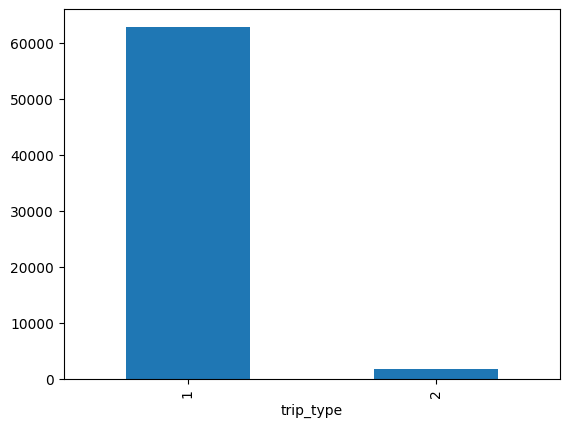

In [33]:
# the most common way that New Yorkers request/hail a cab. 
ways_to_request_cab = tripdata_df["trip_type"].value_counts()
ways_to_request_cab.plot(kind="bar")
# EXPLANATION
print("Based on the bar graph, a majority of New Yorkers request cabs through street hail rather than via dispatch or apps.  "
      + "Based on the data dictionary, 1 represents street hail and 2 represents dispatch.")

Based on the bar graph, the most common pick-up locations are TLC Taxi Zones 74, 75, 166, 41, and 95.  Based on the Taxi Zone lookup on the website, these are all in Manhattan aside from 95 which is in Queens.  Therefore, the most common pickup locations are in Manhattan.  All locations are in the BoroZone service zone.


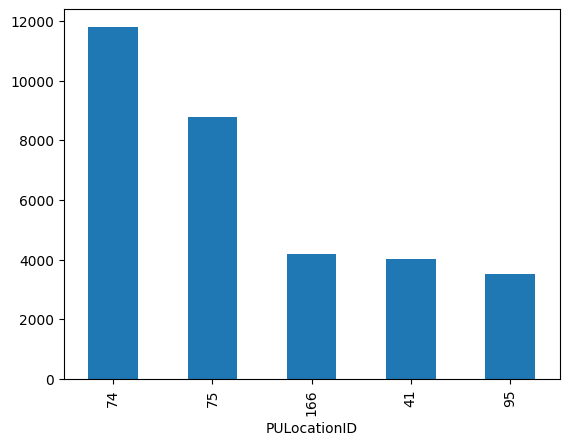

In [34]:
# the most common pick-up locations (display the top 5 locations). 
top5_pickup_locs = tripdata_df["PULocationID"].value_counts().head(5)
top5_pickup_locs.plot(kind="bar")
# EXPLANATION
print("Based on the bar graph, the most common pick-up locations are TLC Taxi Zones 74, 75, 166, "
      + "41, and 95.  Based on the Taxi Zone lookup on the website, these are all in Manhattan aside "
      + "from 95 which is in Queens.  Therefore, the most common pickup locations are in Manhattan.  "
      + "All locations are in the BoroZone service zone.")

Based on the graph, the most common drop-off locations are TLC Taxi Zones 74, 75, 236, 41, and 42.  Based on the Taxi Zone lookup on the website, these are all in Manhattan.  Therefore, the most common pickup locations are in Manhattan.


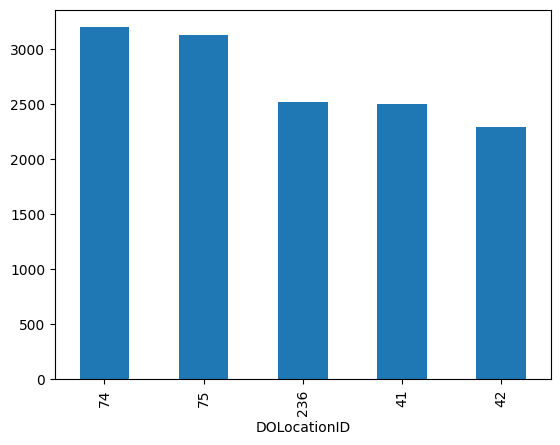

In [35]:
# the most common drop-off locations (display the top 5 locations). 
top5_dropoff_locs = tripdata_df["DOLocationID"].value_counts().head(5)
top5_dropoff_locs.plot(kind="bar")
# EXPLANATION
print("Based on the graph, the most common drop-off locations are TLC Taxi Zones 74, 75, "
      + "236, 41, and 42.  Based on the Taxi Zone lookup on the website, these are all in Manhattan.  "
      + "Therefore, the most common pickup locations are in Manhattan.")

## 7. Data Analysis (10 pts)
Write suitable code to answer the following:
1. On average, how far do New Yorkers usually travel using these taxis?
2. What is the most expensive and least expensive trip? 
3. What is the minimum, average and maximum **tip amount** for all trips that are 1) under 2 miles and 2) over 2 miles (i.e. >= 2)? 

Explain the results.

In [36]:
# 1. On average, how far do New Yorkers usually travel using these taxis?
tripdata_df["trip_distance"].describe()

print("On average, New Yorkers travel 13.7 miles using these taxis.")

On average, New Yorkers travel 13.7 miles using these taxis.


In [37]:
# 2. What is the most expensive and least expensive trip? 
tripdata_df["total_amount"].describe()
cost_filter = tripdata_df["total_amount"] >= 0
filtered_cost_df = tripdata_df[cost_filter]
filtered_cost_df["total_amount"].describe()
print("The most expensive trip is $441 and the least expensive trip is 0.00.")

The most expensive trip is $441 and the least expensive trip is 0.00.


In [38]:
# 3. What is the minimum, average, and maximum **tip amount** for all trips that are 1) under 2 miles and 2) over 2 miles (i.e. >= 2)?
filter_under_2miles = tripdata_df["trip_distance"] < 2
filter_over_2miles = tripdata_df["trip_distance"] >= 2

In [39]:
# 3a
under_2mi_df = tripdata_df[filter_under_2miles]
# verify
under_2mi_df["trip_distance"].value_counts()
under_2mi_df["tip_amount"].describe()
print("The minimum, average, and maximum tip amount for trips under 2 miles are 0.00, 1.35, and 80 respectively.")

The minimum, average, and maximum tip amount for trips under 2 miles are 0.00, 1.35, and 80 respectively.


In [40]:
# 3b
over_2mi_df = tripdata_df[filter_over_2miles]
# verify
over_2mi_df["trip_distance"].value_counts()
over_2mi_df["tip_amount"].describe()
print("The minimum, average, and maximum tip amount for trips over 2 miles are 0.00, 3.05, and 75.82 respectively.  "
      + "Therefore, on average, New Yorkers tend to pay more tip for longer trips over 2 miles.")

The minimum, average, and maximum tip amount for trips over 2 miles are 0.00, 3.05, and 75.82 respectively.  Therefore, on average, New Yorkers tend to pay more tip for longer trips over 2 miles.


## 8. Findings (3 pts)
Based on the preliminary analysis, is this data a viable source that can be used by your team in the future to understand how New Yorkers use these taxis? Justify your response.

In [41]:
# verify how much data actually filtered, clearly majority of data is still there because most missing variables were imputed based on mean/mode 
# depending on variable type
print(f"There are {tripdata_df.shape[0]} rows and {tripdata_df.shape[1]} columns after filtering.")


There are 64616 rows and 19 columns after filtering.


Based on preliminary analysis, this data is a viable source that can be used by the team in the future. A majority of the data was available since at most there were 20 variables and the maximum amount that were missing was 6.  While there were some invalid values such as negative values for congestion_surcharge, improvement_surcharge, tip_amount, and total_amount, the data could still be analyzed after removing this invalid data.  Other variables with missing values were also corrected with imputation based on the mean or mode depending on whether it was quantitative or qualitative data.  This dataset is also relevant to understanding how New Yorkers use taxis whether it be determining popular pick-up or drop-off locations, fares, or additional charges.  